<a href="https://colab.research.google.com/github/janepium/deteccion-anomalias-rt-iot/blob/main/notebooks/05_validacion_variables.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv("dataset_limpio.csv")
print(df.shape)
df.head()

(117922, 38)


,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,flow_pkts_per_sec,...,fwd_iat.std,fwd_subflow_bytes,fwd_bulk_bytes,active.std,idle.tot,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,0.437341,...,1.040307e+07,25.333333,0.0,0.0,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,0.439097,...,1.046346e+07,25.333333,0.0,0.0,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,0.435811,...,1.044238e+07,24.666667,0.0,0.0,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,0.438033,...,1.048253e+07,24.666667,0.0,0.0,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,0.438839,...,1.044702e+07,25.333333,0.0,0.0,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [ ]:
print("Número de columnas:", len(df.columns))

Número de columnas: 38


In [ ]:
constantes = [col for col in df.columns if df[col].nunique() <= 1]
print(constantes)

[]


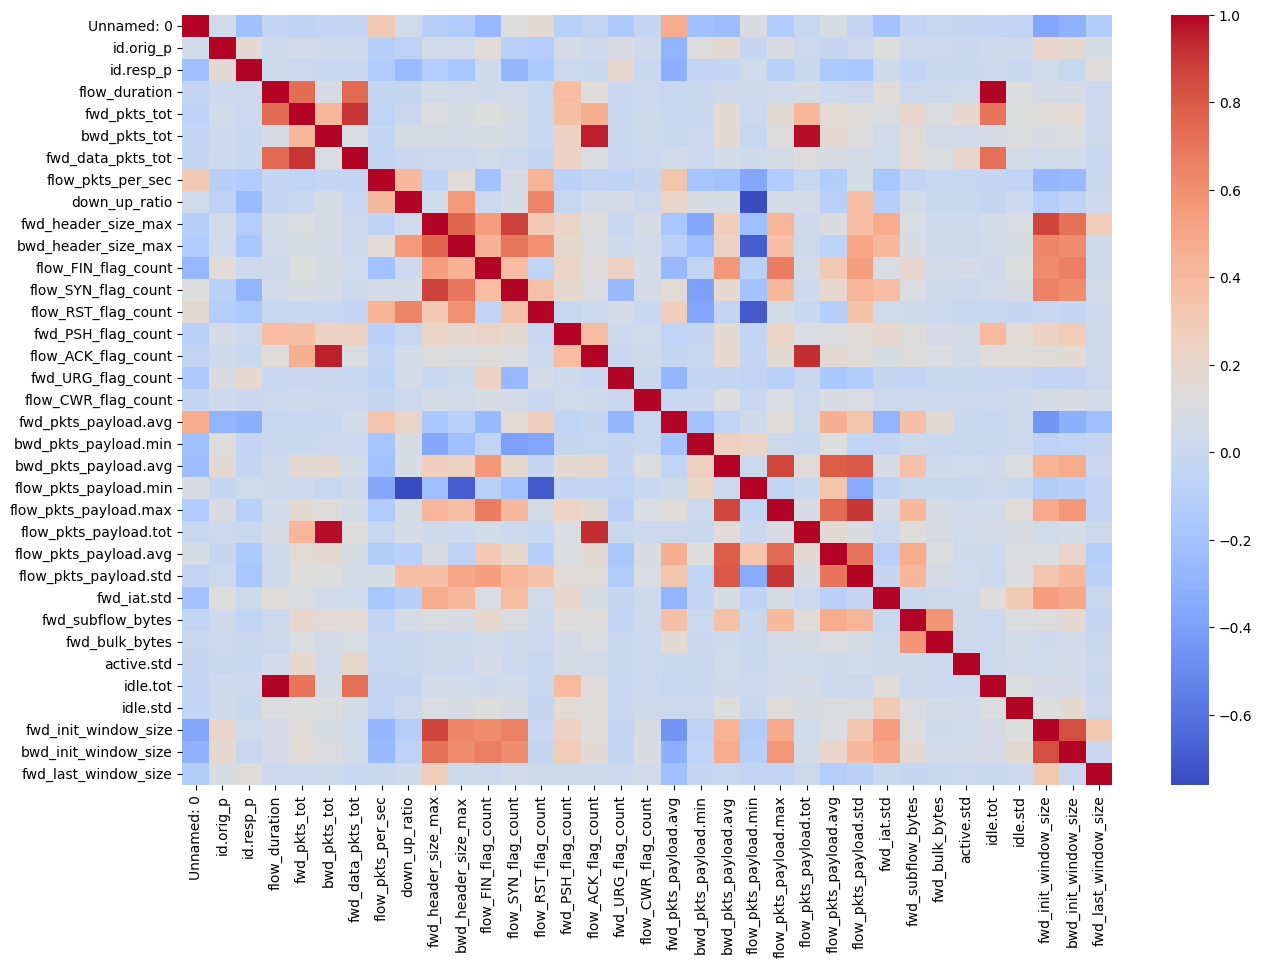

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,10))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

In [ ]:
import numpy as np

corr_matrix = corr.abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

altas_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]

print(altas_corr)

['flow_ACK_flag_count', 'flow_pkts_payload.tot', 'idle.tot']
